# **Analisis Exploratorio de Metrobus**

1. Introducción

2. Objetivos

3. Importación de librerías

4. Configuración de Pandas

5. Carga de datos

6. Resumen general
    - dimensiones
    - memoria
    - nulos
    - duplicados

7. Análisis individual

    * 7.1 Viajes
    * 7.2 Mantenimiento
    * 7.3 Incidencias
    * 7.4 Conductores
    * 7.5 Cocheras
    * 7.6 Líneas
    * 7.7 Paradas
    * 7.8 Tarifas
    * 7.9 Vehículos

8. Conclusiones

## **1. Introducción**

## **2. Objetivos**

## **3. Importación de librerías**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## **4. Configuración de Pandas**

In [4]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar todo el texto en las celdas sin truncar
pd.set_option('display.max_colwidth', None)

## **5. Carga de datos**

In [5]:
# Cargamos los archivos CSV en los DataFrames

# Tablas de hechos
df_viajes = pd.read_csv("../data/raw/fact_viajes.csv").set_index('viaje_id')
df_incidencias = pd.read_csv("../data/raw/fact_incidencias.csv").set_index('incidencia_id')
df_mantenimientos = pd.read_csv("../data/raw/fact_mantenimiento.csv").set_index('mantenimiento_id')

# Tablas de dimensión
df_lineas = pd.read_csv("../data/raw/dim_linea.csv").set_index('linea_id')
df_vehiculos = pd.read_csv("../data/raw/dim_vehiculo.csv").set_index('vehiculo_id')
df_conductores = pd.read_csv("../data/raw/dim_conductor.csv").set_index('conductor_id')
df_paradas = pd.read_csv("../data/raw/dim_parada.csv").set_index('parada_id')
df_tarifas = pd.read_csv("../data/raw/dim_tarifa.csv").set_index('tarifa_id')
df_cocheras = pd.read_csv("../data/raw/dim_depot.csv").set_index('depot_id')

## **6. Resumen general**

En este apartado analizamos la estructura de cada tabla para identificar:

* Total de columnas
* Total de filas
* Total de nulos
* Porcentaje de nulos
* Total de duplicados
* Memoria utilizada

In [6]:
dataframes = {
    "viajes": df_viajes,
    "incidencias": df_incidencias,
    "mantenimiento": df_mantenimientos,
    "lineas": df_lineas,
    "vehiculos": df_vehiculos,
    "conductores": df_conductores,
    "paradas": df_paradas,
    "tarifas": df_tarifas,
    "cocheras": df_cocheras
}

In [7]:
# Obtenemos un nuevo DataFrame con los metadatos de todos los datasets
metadatos = {
    'DataFrame': [],
    'Columnas': [],
    'Filas': [],
    'Nulos': [],
    '% Nulos': [],
    'Duplicados': [],
    'Memoria MB': []
}

for name, dataframe in dataframes.items():
    nulos = dataframe.isnull().sum().sum()
    filas = dataframe.shape[0]

    metadatos["DataFrame"].append(name)
    metadatos["Columnas"].append(dataframe.shape[1])
    metadatos["Filas"].append(filas)
    metadatos["Nulos"].append(nulos)
    metadatos["% Nulos"].append(round(((nulos/filas) * 100), 2))
    metadatos["Duplicados"].append(dataframe.duplicated().sum())
    metadatos["Memoria MB"].append(round(dataframe.memory_usage(deep=True).sum() / (1024 **2), 3))

df_estructura_general = pd.DataFrame(metadatos).set_index('DataFrame')
df_estructura_general

,Columnas,Filas,Nulos,% Nulos,Duplicados,Memoria MB
DataFrame,,,,,,
viajes,23,50000,1105,2.21,0,22.212
incidencias,15,4000,0,0.00,0,1.378
mantenimiento,14,876,15,1.71,0,0.317
lineas,6,10,0,0.00,0,0.002
vehiculos,11,45,1,2.22,0,0.010
conductores,9,30,1,3.33,0,0.008
paradas,9,120,2,1.67,0,0.029
tarifas,5,9,0,0.00,0,0.001
cocheras,5,3,0,0.00,0,0.000


## **7. Análisis individual**

En este apartado se realiza un análisis individual de cada tabla del dataset con el objetivo de comprender su estructura, calidad y distribución de los datos.

Para cada columna se analizan los siguientes aspectos:

* Tipo de dato de cada atributo.
* Número total de valores nulos.
* Porcentaje de valores nulos respecto al total de registros.
* Cantidad de valores únicos para conocer la cardinalidad de los datos.
* Moda de cada columna para identificar los valores más repetidos.
* Número total de filas y columnas de cada tabla.
* Valor más frecuente (`top`) y su frecuencia (`freq`) de aparición.
* Medidas estadísticas descriptivas para variables numéricas:
  * Media.
  * Desviación estándar.
  * Moda
  * Valor mínimo.
  * Valor máximo.

Este análisis permite detectar problemas de calidad de datos, identificar posibles valores atípicos y comprender la distribución de las variables antes de realizar las transformaciones y análisis posteriores.

Posteriormente, se realizará un **análisis específico de los valores atípicos (outliers)** presentes en las variables numéricas.

En primer lugar, se utilizarán **histogramas** con el objetivo de observar visualmente la **distribución de los datos** y determinar si presentan una distribución **normal** o no.

Una vez analizada la distribución, se seleccionará el método adecuado para la **detección de valores atípicos**:

* Para variables que **no presenten una distribución normal**, se empleará el **Método del Rango Intercuartílico (IQR)**.
* Para variables con una **distribución normal**, se utilizará la **Puntuación Z (Z-Score)**.

Finalmente, se utilizarán **diagramas de caja (Box Plot)** para representar visualmente la distribución de los datos y facilitar la **identificación de posibles valores atípicos**.


In [8]:
def es_numero(columna):
    return columna.dtype in [int, float, bool]

def es_object(columna):
    return columna.dtype in [object, str]

In [9]:
def pasar_int_a_str(lista):
    return [str(n) for n in lista]

def obtener_valores(columna):
    return ", ".join([str(x) for x in columna.dropna().unique()[:3]])

In [10]:
def calcular_nulos(columna):
    return columna.isnull().sum()

def calcular_porcentaje_nulos(columna):
    return round((calcular_nulos(columna)/ columna.size) * 100, 2)

def calcular_valores_unicos(columna):
    return len(columna.unique())

def calcular_top(columna):
    return columna.value_counts().index[0] if es_object(columna) else np.nan

def calcular_frecuencia(columna):
    return columna.value_counts().iloc[0] if es_object(columna) else np.nan

def calcular_media(columna):
    return round( np.mean(columna), 2) if es_numero(columna) else np.nan

def calcular_std(columna):
    return round(np.std(columna), 2) if es_numero(columna) else np.nan

def calcular_moda(columna):
    lista_con_str = pasar_int_a_str(list(columna.mode())[:6])
    resultado = " - ".join(lista_con_str) + " - ..." if len(lista_con_str) > 5 else ("".join(lista_con_str) if len(lista_con_str) == 1 else " - ".join(lista_con_str))
    
    return resultado if es_numero(columna) else np.nan

def calcular_min(columna):
    return columna.min() if es_numero(columna) else np.nan

def calcular_max(columna):
    return columna.max() if es_numero(columna) else np.nan

In [11]:
def crear_tabla_metadatos(df):

    return pd.DataFrame(
                data= {
                        'Columna': df.columns,
                        'Tipo_Dato': df.dtypes,
                        'Valores_Nulos': df.apply(calcular_nulos, axis=0), 
                        'Porcentaje_Nulos': df.apply(calcular_porcentaje_nulos, axis=0),
                        'Valores_Unicos': df.apply(calcular_valores_unicos, axis=0),
                        'Filas': df.shape[0],
                        'Columnas': df.shape[1],
                        'Media': df.apply(calcular_media, axis=0),
                        'Desviacion': df.apply(calcular_std, axis=0),
                        'Moda': df.apply(calcular_moda, axis=0),
                        'Minimo': df.apply(calcular_min, axis=0),
                        'Maximo': df.apply(calcular_max, axis=0),
                        'Top': df.apply(calcular_top, axis=0),
                        'Frecuencia_Moda': df.apply(calcular_frecuencia, axis=0),
                        'Ejemplo de Valores (Max.3)': df.apply(obtener_valores, axis=0)

                }).set_index('Columna').sort_values(by='Tipo_Dato')  # Ordena las columnas por tipo de dato para agrupar los valores estadísticos válidos y evitar la alternancia entre valores y NaN.

In [12]:
def crear_boxplot(df, columna):
    plt.figure(figsize=(10, 6))

    plt.boxplot(
        df[columna].dropna()                                                                          
    )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    
    plt.tight_layout()                                           
    plt.show()

In [ ]:
import math

def crear_boxplot_general(df):

    columns_name = df.columns
    len_columns = len(columns_name)

    filas = 4 if len_columns >= 4 else 1        # TODO FALLO LEN 1 IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed
    columns = math.ceil(len_columns / filas)    # TODO FALLO
                                                # TODO MODIFICAR ESTRATEGIA OUTLIERS
    fig, axs = plt.subplots(
        nrows= filas, 
        ncols= columns, 
        figsize=(20, 16)
    ) 

    contador = 0

    for i in range(filas):

        for c in range(columns):
            nombre = columns_name[contador]

            sns.boxplot(                               
                    data= df[nombre], 
                    ax= axs[i, c]
                )
            
            axs[i, c].set_title(nombre, fontsize=12)
            axs[i, c].xaxis.set_visible(False)               
            axs[i, c].yaxis.set_visible(False)   

            if (contador == len_columns - 1):
                return
            
            contador += 1           

    # Configuracion General Grafica
    axs.xaxis.set_visible(False)
    axs.yaxis.set_visible(False)

    axs.spines['left'].set_visible(False)
    axs.spines['top'].set_visible(False)
    axs.spines['bottom'].set_visible(False)
    axs.spines['right'].set_visible(False)

    fig.suptitle(
        "Boxplot de las variables numéricas",
        fontsize=22,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

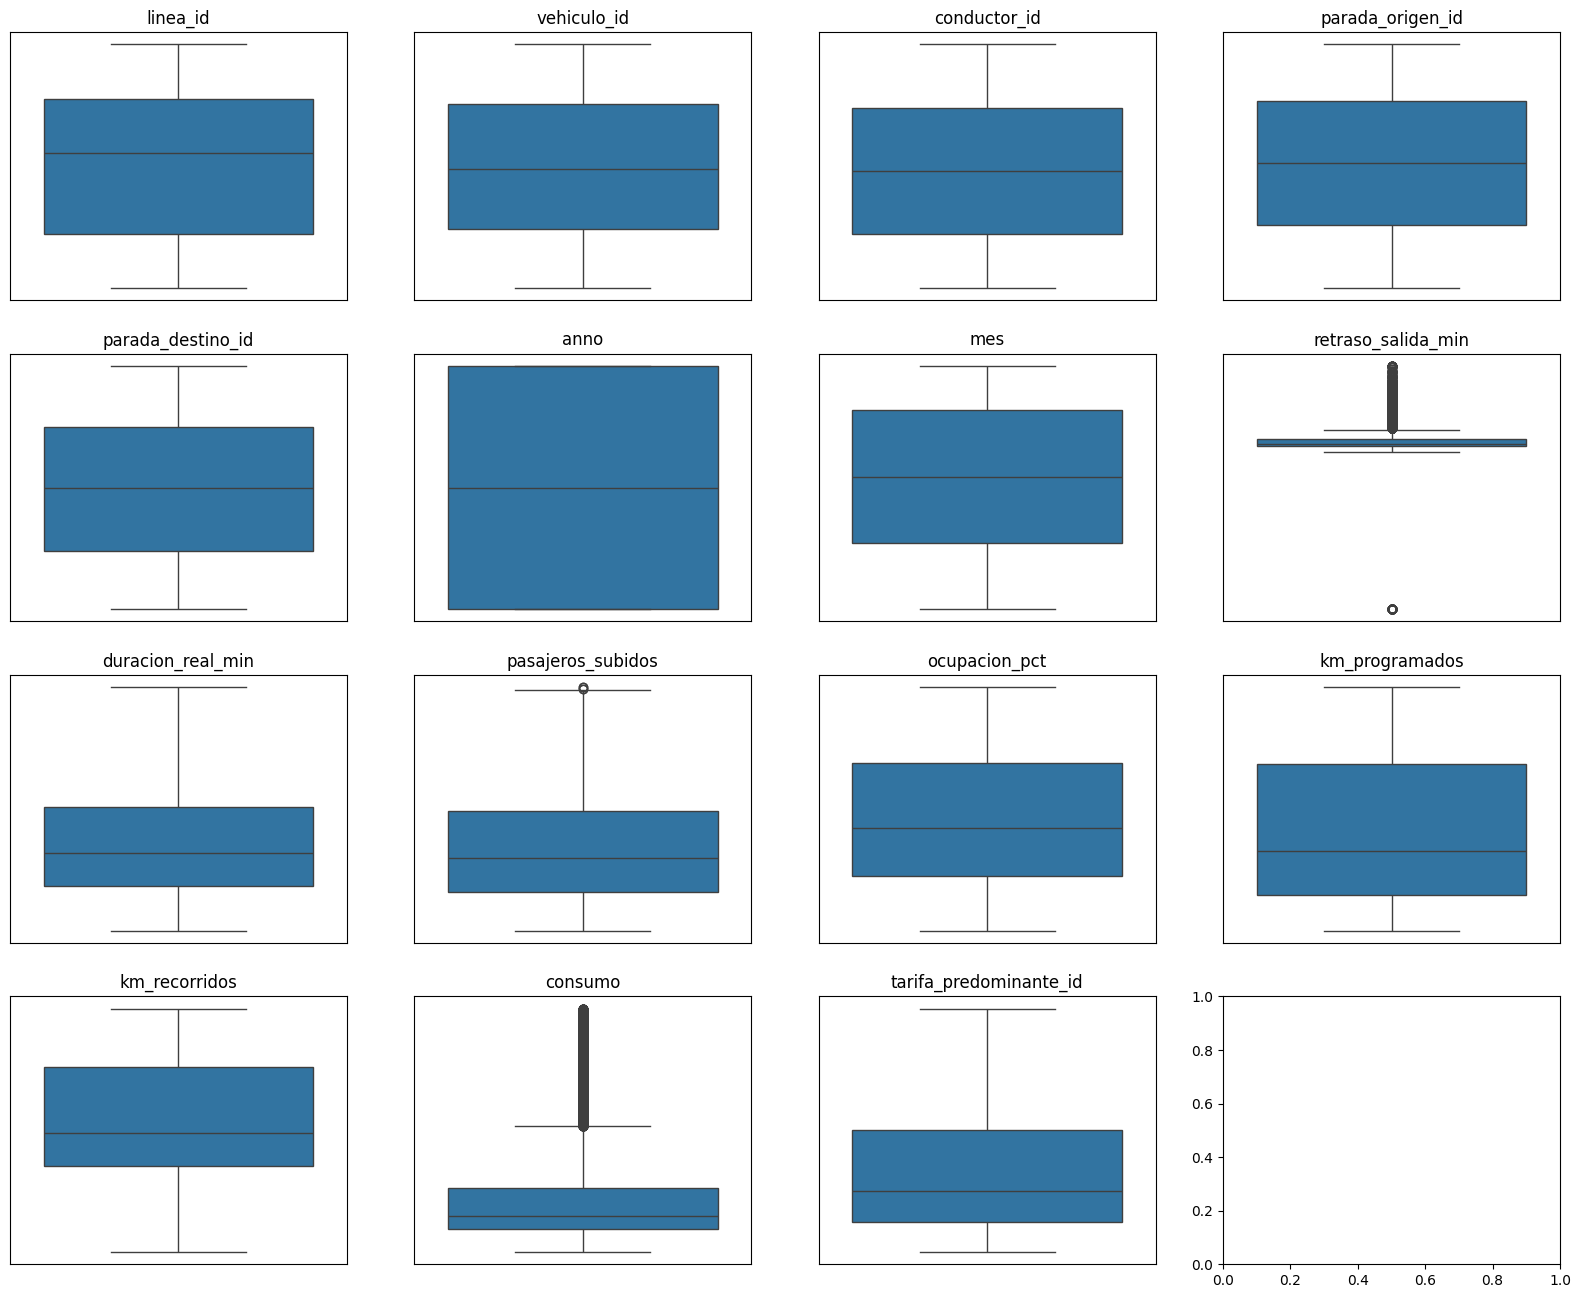

In [66]:
crear_boxplot_general(df_viajes.select_dtypes(include="number"))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

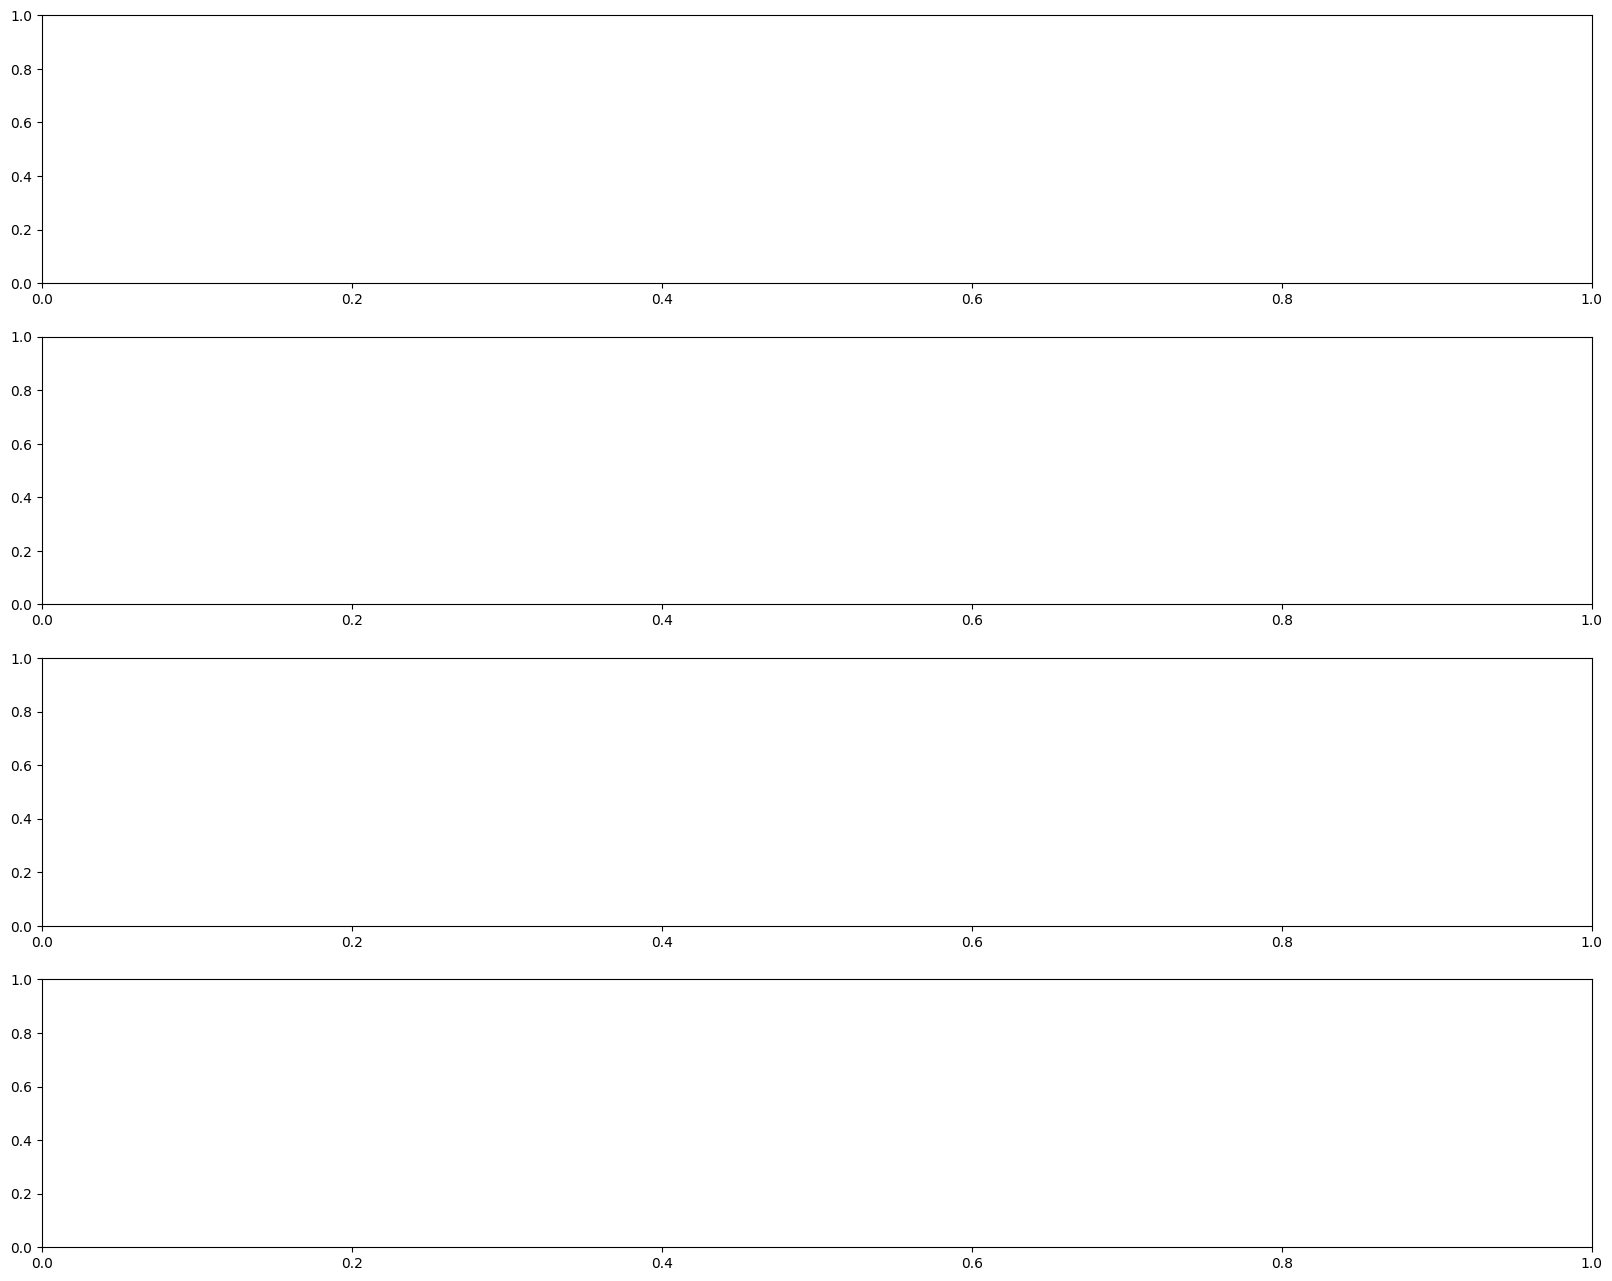

In [65]:
crear_boxplot_general(df_conductores.select_dtypes(include="number"))

In [ ]:
def crear_histograma(df, columna):
    plt.figure(figsize=(10, 5))

    plt.hist(
        df[columna].dropna(), 
        bins="auto", 
        linewidth= 0.75,
        edgecolor="black"    
        )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

In [ ]:
def calcular_z_score(df, columna, z_threshold = 2.8):
    df = df.dropna(how='all', subset=[columna])
    df_z_score = df[np.abs(stats.zscore(df[columna].dropna())) > z_threshold][columna]
    
    print("Valores atípicos detectados con Z-score: " + str(df_z_score.size))
    return df_z_score

In [ ]:
def calcular_iqr(df, columna):
    df = df.dropna(how='all', subset=[columna])

    iqr_value = stats.iqr(df[columna])
    q1, q3 = np.quantile(df[columna], [0.25, 0.75])

    lower = q1 - 1.5 * iqr_value
    upper = q3 + 1.5 * iqr_value

    df_iqr = df[(df[columna] < lower) | (df[columna]> upper)][columna]
    print("\nValores atípicos detectados con IQR: " + str(df_iqr.size))
    
    return df_iqr

## **7.1 Viajes**

### **7.1.1 Analisis Inicial**

In [ ]:
df_viajes.head(3)

In [ ]:
df_viajes_metadatos = crear_tabla_metadatos(df_viajes)
df_viajes_metadatos

In [ ]:
df_viajes.retraso_salida_min.min()

In [ ]:
df_viajes.dia_semana.unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_viajes` permite concluir que, en términos generales, la tabla presenta una buena calidad de los datos, ya que la mayoría de las columnas no contienen valores nulos y el rango de los valores es coherente. No obstante, se han identificado varios aspectos que requieren una revisión más detallada en las siguientes fases del EDA: 

* La columna **dia_semana** presenta 14 valores únicos, un rango superior a lo esperado para una variable que representa los días de la semana. 

* La columna **consumo** contiene 1.065 valores nulos (2,13 %), siendo la variable con mayor cantidad de datos ausentes. Asimismo, la columna **pasajeros_subidos** presenta un total de 40 valores nulos (0,08 %).

* También se ha detectado que la variable **retraso_salida_min** tiene un valor mínimo de -99 minutos, un dato poco plausible desde el punto de vista operativo.

Por último, las columnas **fecha, hora_salida_real, hora_llegada_real y hora_salida_prog** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

In [ ]:
df_viajes_metadatos

### **7.1.2 Outliers**

In [ ]:
fig, ax = plt.subplots(figsize=(18, 12), sharex=False, sharey=True)

ax1 = plt.subplot2grid((2, 4), (0, 0), 1, 1)
ax2 = plt.subplot2grid((2, 4), (0, 1), 1, 1)
ax3 = plt.subplot2grid((2, 4), (0, 2), 1, 1)
ax4 = plt.subplot2grid((2, 4), (0, 3), 1, 1)
ax5 = plt.subplot2grid((2, 4), (1, 0), 1, 1)
ax6 = plt.subplot2grid((2, 4), (1, 1), 1, 1)
ax7 = plt.subplot2grid((2, 4), (1, 2), 1, 1)


sns.boxplot(
    data=df_viajes["retraso_salida_min"],
    ax=ax1
)

sns.boxplot(
    data=df_viajes["duracion_real_min"],
    ax=ax2
)

sns.boxplot(
    data=df_viajes["pasajeros_subidos"],
    ax=ax3
)

sns.boxplot(
    data=df_viajes["ocupacion_pct"],
    ax=ax4
)

sns.boxplot(
    data=df_viajes["km_programados"],
    ax=ax5
)

sns.boxplot(
    data=df_viajes["km_recorridos"],
    ax=ax6
)

sns.boxplot(
    data=df_viajes["consumo"],
    ax=ax7
)


ax1.set_title("Retraso salida")
ax2.set_title("Duración real")
ax3.set_title("Pasajeros subidos")
ax4.set_title("Ocupación (%)")
ax5.set_title("KM programados")
ax6.set_title("KM recorridos")
ax7.set_title("Consumo")

ax1.xaxis.set_visible(False)
ax1.yaxis.set_visible(False)

ax2.xaxis.set_visible(False)
ax2.yaxis.set_visible(False)

ax3.xaxis.set_visible(False)
ax3.yaxis.set_visible(False)

ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)

ax5.xaxis.set_visible(False)
ax5.yaxis.set_visible(False)

ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)

ax7.xaxis.set_visible(False)
ax7.yaxis.set_visible(False)

ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)

ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle(
    "Distribución de las variables numéricas",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **7.1.2.1 Consumo**

In [ ]:
crear_histograma(df_viajes , "consumo")

In [ ]:
calcular_z_score(df_viajes, "consumo")

In [ ]:
calcular_iqr(df_viajes, "consumo")

In [ ]:
crear_boxplot(df_viajes, "consumo")

#### **7.1.2.2 Duracion Real Min**

In [ ]:
crear_histograma(df_viajes, "duracion_real_min")

In [ ]:
calcular_iqr(df_viajes, "duracion_real_min")

In [ ]:
calcular_z_score(df_viajes, "duracion_real_min")

In [ ]:
crear_boxplot(df_viajes, "duracion_real_min")

#### **7.1.2.3 Retraso Salida Min**

In [ ]:
df_retraso_sin_min = df_viajes[df_viajes["retraso_salida_min"] > -20]

In [ ]:
crear_histograma(df_retraso_sin_min, "retraso_salida_min") # Excluidmos el valor -99

In [ ]:
calcular_iqr(df_retraso_sin_min, "retraso_salida_min")

In [ ]:
calcular_z_score(df_retraso_sin_min, "retraso_salida_min")

In [ ]:
crear_boxplot(df_retraso_sin_min, "retraso_salida_min")

## **7.2 Mantenimiento**

In [ ]:
df_mantenimientos.head(3)

In [ ]:
df_mantenimientos_metadatos = crear_tabla_metadatos(df_mantenimientos)
df_mantenimientos_metadatos

In [ ]:
df_mantenimientos.coste_eur[df_mantenimientos.coste_eur < 0.00].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame df_mantenimiento permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024.

*  La columna **coste_euros** presenta valores negativos, un comportamiento que no resulta coherente desde el punto de vista operativo.

* La columna **categoria** presenta 15 valores nulos, lo que representa aproximadamente un 1,71 % del total de registros.

Por ultimo, Las columnas relacionadas con **fechas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

## **7.3 Incidencias**

In [ ]:
df_incidencias.head(3)

In [ ]:
df_incidencias_metadatos = crear_tabla_metadatos(df_incidencias)
df_incidencias_metadatos

In [ ]:
df_incidencias[df_incidencias.coste_estimado_eur == 0].head(3)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_incidencias` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **coste_estimado_eur** presenta valores iguales a 0.00, un comportamiento que apriori no resulta coherente desde el punto de vista operativo.

* Las columnas relacionadas con **fechas** y **horas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

## **7.4 Conductores**

In [ ]:
df_conductores.head(3)

In [ ]:
df_conductores_metadatos = crear_tabla_metadatos(df_conductores)
df_conductores_metadatos

In [ ]:
df_conductores['turno_habitual'].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_conductores` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024. 

* La variable **turno_habitual** presenta una inconsistencia en la codificación de categorías, ya que aparecen los valores Manana (06-14h) y manana, que representan el mismo turno.

## **7.5 Cocheras**

In [ ]:
df_cocheras.head(3)

In [ ]:
df_cocheras_metadatos = crear_tabla_metadatos(df_cocheras)
df_cocheras_metadatos

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_cocheras` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.6 Lineas**

In [ ]:
df_lineas.head(10)

In [ ]:
df_lineas_metadatos = crear_tabla_metadatos(df_lineas)
df_lineas_metadatos

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_lineas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.7 Paradas**

In [ ]:
df_paradas.head(3)

In [ ]:
df_paradas_metadatos = crear_tabla_metadatos(df_paradas)
df_paradas_metadatos

In [ ]:
df_paradas.accesible_silla.unique()

In [ ]:
df_paradas.latitud.max()

In [ ]:
df_paradas.barrio.unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_paradas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **latitud** presenta 1 valor nulo (0,83 %). Del mismo modo, la columna **accesible_silla** también contiene 1 valor nulo (0,83 %).

* La variable **accesible_silla** está almacenada con tipo de dato object, aunque únicamente contiene valores booleanos (True y False). 

* La columna **latitud** presenta un valor máximo de 999.0, claramente fuera del rango válido para una coordenada geográfica. 

* La variable **barrio** presenta inconsistencias en la estandarización de sus valores, ya que existen registros que hacen referencia a una misma categoría pero aparecen representados de diferentes formas. Por ejemplo, valores como 'Barrio Norte' y 'BARRIO NORTE'.

## **7.8 Tarifas**

In [ ]:
df_tarifas.head(9)

In [ ]:
df_tarifas_metadatos = crear_tabla_metadatos(df_tarifas)
df_tarifas_metadatos

In [ ]:
df_tarifas[df_tarifas['precio_eur'] == 0.0]

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_tarifas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.9 Vehiculos**

In [ ]:
df_vehiculos.head(3)

In [ ]:
df_vehiculos_metadatos = crear_tabla_metadatos(df_vehiculos)
df_vehiculos_metadatos

In [ ]:
df_vehiculos['anno_fabricacion'].unique()

In [ ]:
df_vehiculos['km_totales'].unique()

In [ ]:
df_vehiculos[df_vehiculos['emisiones_co2_gkm'] == 0]

In [ ]:
df_vehiculos['combustible'].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_vehiculos` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **año_fabricacion** presenta un valor máximo de 2099, un dato claramente incoherente que deberá verificarse, ya que probablemente corresponda a un error de captura o de generación de los datos.

* La variable **km_totales** contiene un valor mínimo de -500 km, un registro imposible desde el punto de vista operativo.

* La columna **emisiones_co2_gkm** presenta valores iguales a 0 g/km. Tras revisar el conjunto de datos, se observa que estos registros corresponden a vehículos eléctricos.

* La variable **combustible** presenta una falta de estandarización en sus categorías, ya que aparecen los valores Diesel y diesel, que representan el mismo tipo de combustible.

## **8. Conclusión**